# Default Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pprint import pprint
from imdb import IMDb
from imdb import IMDbDataAccessError
import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import json
import time
from time import sleep

In [2]:
import pickle as pkl

In [16]:
imdb = IMDb()

In [17]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
import warnings
warnings.filterwarnings('ignore')

# 30/12/2023 

In [6]:
genres_grouped = pd.read_csv('datasets/genres_grouped.csv').drop(columns = 'Unnamed: 0')

In [7]:
genres_grouped.head()

,genres,movie_imdb_id
0,Drama,3829
1,Comedy,3055
2,Action,2682
3,Thriller,2582
4,Adventure,1839


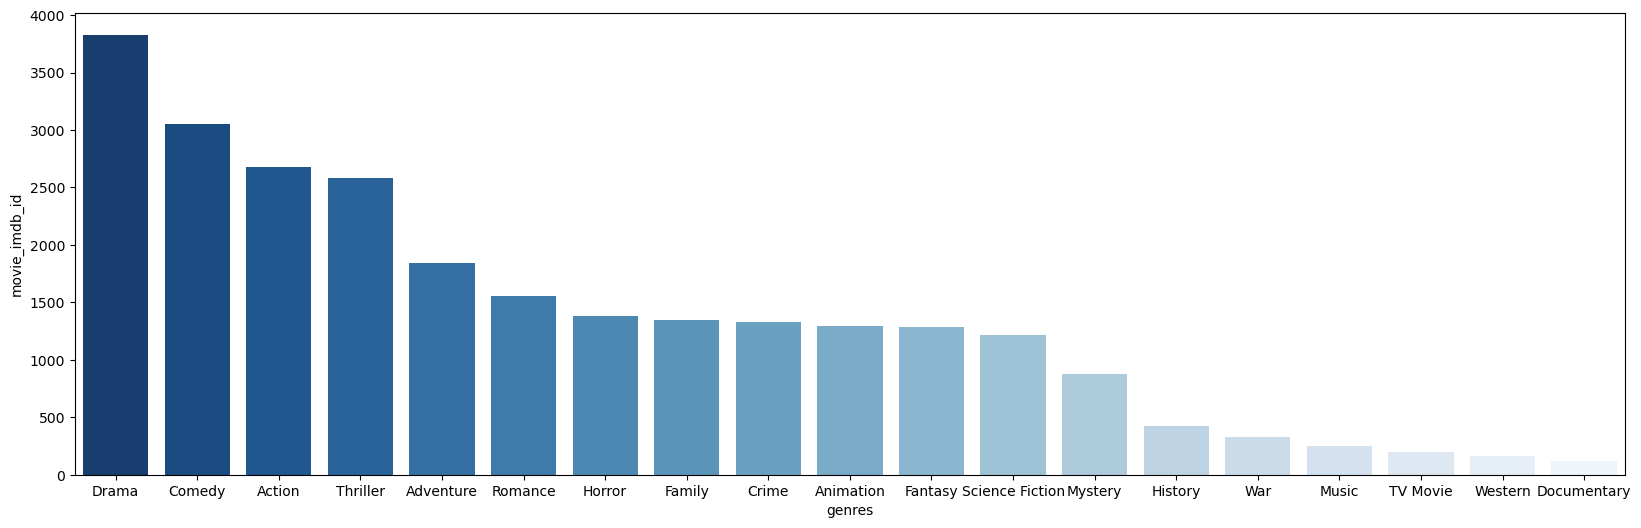

In [8]:
plt.figure(figsize=(20,6))
sns.barplot(x = 'genres',y= 'movie_imdb_id',data=genres_grouped.head(20),palette='Blues_r')
plt.show()

In [9]:
keywords_grouped = pd.read_csv('datasets/keyword_grouped.csv').drop(columns = 'Unnamed: 0')

In [10]:
keywords_grouped.head()

,keywords,movie_imdb_id
0,based on novel or book,1015
1,murder,513
2,sequel,464
3,woman director,408
4,duringcreditsstinger,405


In [11]:
keywords_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14781 entries, 0 to 14780
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   keywords       14781 non-null  object
 1   movie_imdb_id  14781 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 231.1+ KB


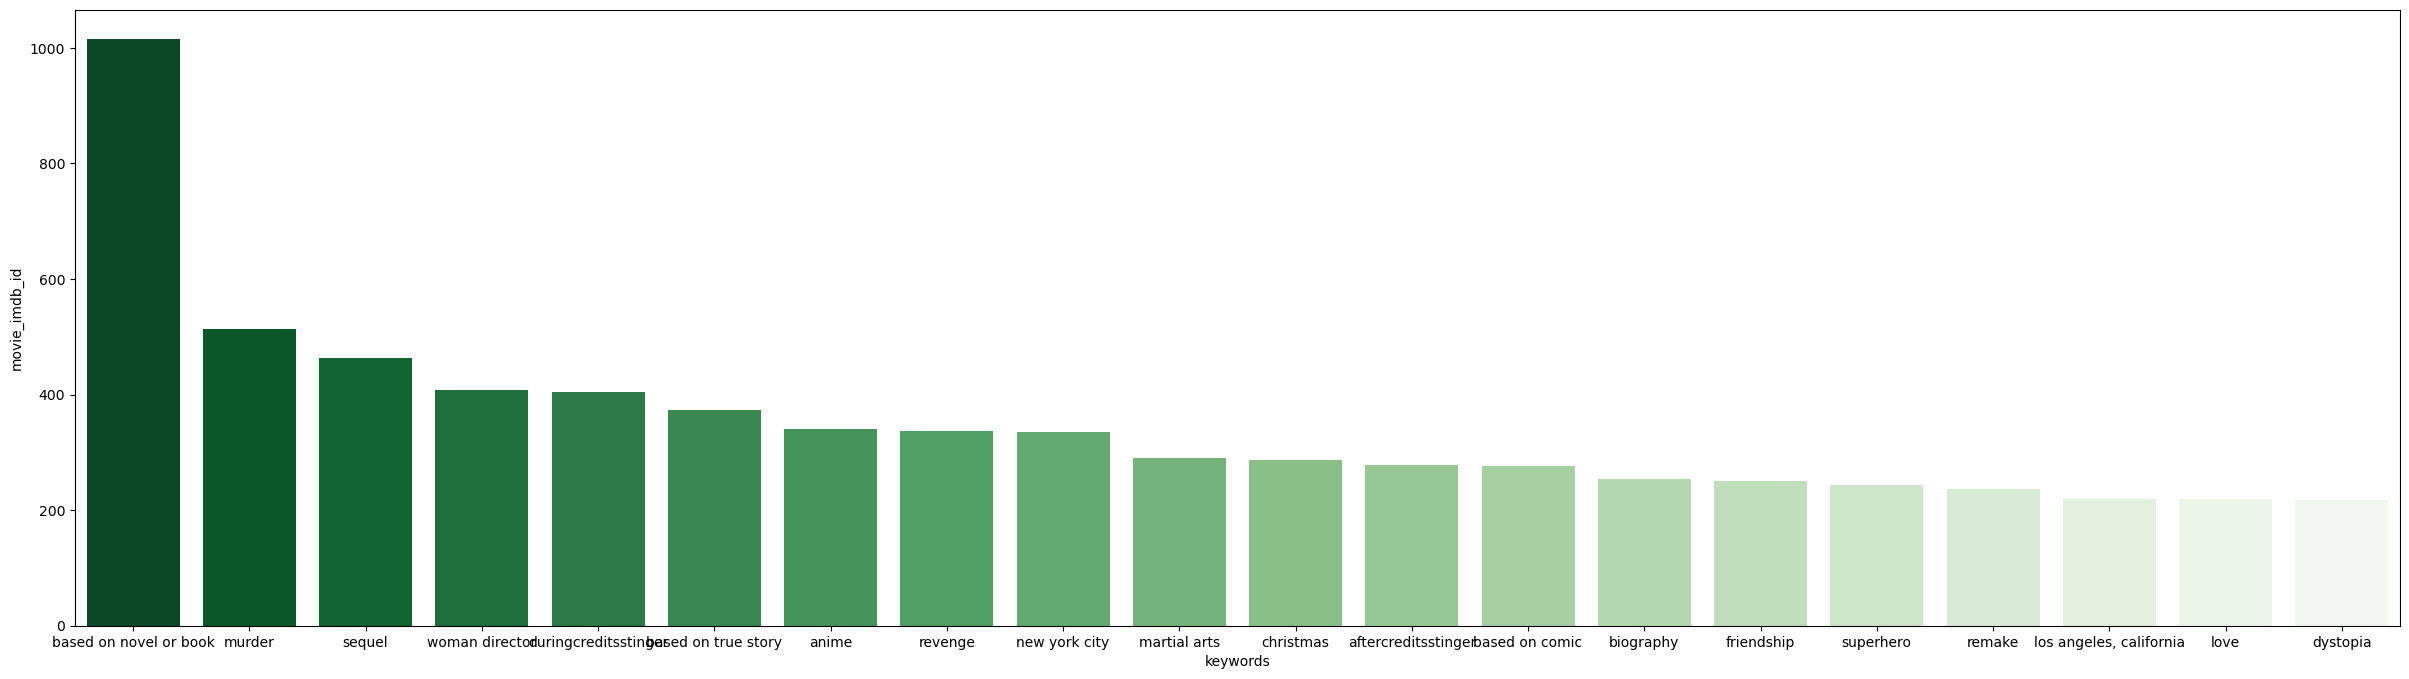

In [12]:
plt.figure(figsize = (30,8))
sns.barplot(x = 'keywords',y= 'movie_imdb_id',data=keywords_grouped.head(20),palette='Greens_r')
plt.show()

-----------------------------------------------------------------------------------------------------------------------------------

In [13]:
movies_df = pd.read_json('datasets/movies_df_handling.json').T

In [14]:
movies_df.head()

,id,title,overview,genres,keywords,release_date,director,director_popularity,movie_popularity,movie_imdb_id,averageRating,numVotes,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes
0,1075794,Leo,Jaded 74-year-old lizard Leo has been stuck in...,"[Animation, Comedy, Family]","[classroom, musical, bucket list]",2023-11-17,"[Robert Smigel, Robert Marianetti, David Wacht...","[8.964, 8.263, 4.085]",1661.593,tt5755238,7.0,10041,movie,Leo,Leo,0,2023,\N,102
1,901362,Trolls Band Together,"When Branch’s brother, Floyd, is kidnapped for...","[Animation, Family, Music, Fantasy, Comedy]","[pop star, brother, musical, sequel, based on ...",2023-10-12,[Walt Dohrn],[10.381],1064.93,tt14362112,6.0,5138,movie,Trolls Band Together,Trolls Band Together,0,2023,\N,91
2,872585,Oppenheimer,The story of J. Robert Oppenheimer's role in t...,"[Drama, History]","[husband wife relationship, based on novel or ...",2023-07-19,[Christopher Nolan],[31.607],1020.836,tt15398776,8.5,524717,movie,Oppenheimer,Oppenheimer,0,2023,\N,180
3,507089,Five Nights at Freddy's,"Recently fired and desperate for work, a troub...","[Horror, Mystery]","[night shift, child murder, restaurant, custod...",2023-10-25,[Emma Tammi],[9.397],759.232,tt4589218,5.5,73305,movie,Five Nights at Freddy's,Five Nights at Freddy's,0,2023,\N,109
4,670292,The Creator,Amid a future war between the human race and t...,"[Science Fiction, Action, Thriller]","[artificial intelligence (a.i.), asia, distant...",2023-09-27,[Gareth Edwards],[6.467],702.008,tt11858890,6.9,78610,movie,The Creator,The Creator,0,2023,\N,133


In [15]:
genres_exploded = movies_df.explode('genres')

In [16]:
genres_exploded.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 25787 entries, 0 to 9703
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   25787 non-null  object
 1   title                25787 non-null  object
 2   overview             25787 non-null  object
 3   genres               25777 non-null  object
 4   keywords             25787 non-null  object
 5   release_date         25787 non-null  object
 6   director             25787 non-null  object
 7   director_popularity  25787 non-null  object
 8   movie_popularity     25787 non-null  object
 9   movie_imdb_id        25787 non-null  object
 10  averageRating        25787 non-null  object
 11  numVotes             25787 non-null  object
 12  titleType            25787 non-null  object
 13  primaryTitle         25787 non-null  object
 14  originalTitle        25787 non-null  object
 15  isAdult              25787 non-null  object
 16  start

In [17]:
genres_grouped = genres_exploded.groupby('genres')

In [18]:
genres_popularity = genres_grouped['movie_popularity'].agg(['mean','max','min','count'])

In [19]:
genres_popularity

,mean,max,min,count
genres,,,,
Action,36.966338,702.008,14.959,2682
Adventure,38.045655,606.907,14.972,1839
Animation,37.088764,1661.593,14.986,1297
Comedy,29.416658,1661.593,14.956,3055
Crime,28.532463,555.213,14.963,1329
Documentary,21.945862,89.958,14.986,123
Drama,27.259243,1020.836,14.957,3829
Family,36.645510,1661.593,14.957,1350
Fantasy,37.392880,1064.930,14.969,1286


In [20]:
genres_popularity.rename(columns = lambda x: f'popularity_{x}',inplace=True)

<hr>

In [21]:
genres_keywords_df = pd.read_csv('datasets/genres_keyword.csv').drop(columns =  'Unnamed: 0')

In [22]:
genres_keywords_df.head()

,genres,keywords,movie_imdb_id
0,Drama,based on novel or book,618
1,Animation,anime,339
2,Thriller,murder,333
3,Drama,based on true story,328
4,Thriller,based on novel or book,286


In [23]:
genres_keywords_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72702 entries, 0 to 72701
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   genres         72702 non-null  object
 1   keywords       72702 non-null  object
 2   movie_imdb_id  72702 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [24]:
analysis_test = genres_keywords_df.set_index('genres')

In [25]:
analysis_test['keywords'].unique()

array(['based on novel or book', 'anime', 'murder', ...,
       'kidney transplant ', 'kids speaking', 'kinky sex'], dtype=object)

In [187]:
def heatmap_prepare_data(keyword):
        keyword_df = analysis_test.query(f'keywords == "{keyword}"').drop(columns = 'keywords').rename(columns = {'movie_imdb_id':keyword})
        return keyword_df

In [200]:
dfs = []
for col in tqdm(analysis_test.keywords.unique()):
    dfs.append(heatmap_prepare_data(col))

100%|███████████████████████████████████████████████████████████████████████████| 14781/14781 [01:09<00:00, 211.69it/s]


In [204]:
heatmap_df = pd.concat(dfs,axis = 1).T

In [213]:
heatmap_df.fillna(0,inplace= True)

In [214]:
heatmap_df.head(10)

genres,Drama,Thriller,Romance,Adventure,Comedy,Action,Fantasy,Crime,Mystery,Family,Science Fiction,Horror,Animation,History,War,Western,Music,TV Movie,Documentary
based on novel or book,618.0,286.0,229.0,200.0,191.0,182.0,156.0,148.0,122.0,119.0,113.0,105.0,69.0,68.0,56.0,22.0,7.0,6.0,4.0
anime,97.0,15.0,52.0,136.0,50.0,168.0,160.0,14.0,24.0,50.0,108.0,10.0,339.0,2.0,4.0,0.0,8.0,2.0,0.0
murder,177.0,333.0,25.0,29.0,45.0,118.0,16.0,203.0,145.0,3.0,43.0,192.0,7.0,12.0,3.0,15.0,3.0,3.0,0.0
based on true story,328.0,94.0,30.0,30.0,53.0,54.0,3.0,78.0,14.0,12.0,2.0,16.0,2.0,130.0,42.0,2.0,8.0,4.0,1.0
martial arts,61.0,98.0,13.0,86.0,72.0,276.0,39.0,67.0,3.0,20.0,48.0,12.0,34.0,13.0,8.0,3.0,1.0,1.0,0.0
duringcreditsstinger,63.0,57.0,53.0,130.0,249.0,140.0,63.0,41.0,17.0,100.0,68.0,33.0,68.0,11.0,8.0,3.0,14.0,0.0,1.0
biography,233.0,21.0,23.0,8.0,25.0,19.0,1.0,31.0,5.0,5.0,1.0,2.0,2.0,102.0,30.0,2.0,19.0,6.0,9.0
woman director,227.0,69.0,128.0,42.0,165.0,47.0,46.0,26.0,18.0,58.0,32.0,46.0,33.0,15.0,6.0,2.0,15.0,5.0,4.0
based on comic,27.0,45.0,7.0,140.0,68.0,220.0,81.0,41.0,19.0,40.0,126.0,21.0,82.0,0.0,3.0,2.0,2.0,4.0,0.0
superhero,16.0,22.0,4.0,129.0,55.0,220.0,75.0,28.0,13.0,41.0,130.0,8.0,90.0,0.0,2.0,1.0,1.0,5.0,1.0


<AxesSubplot: xlabel='genres'>

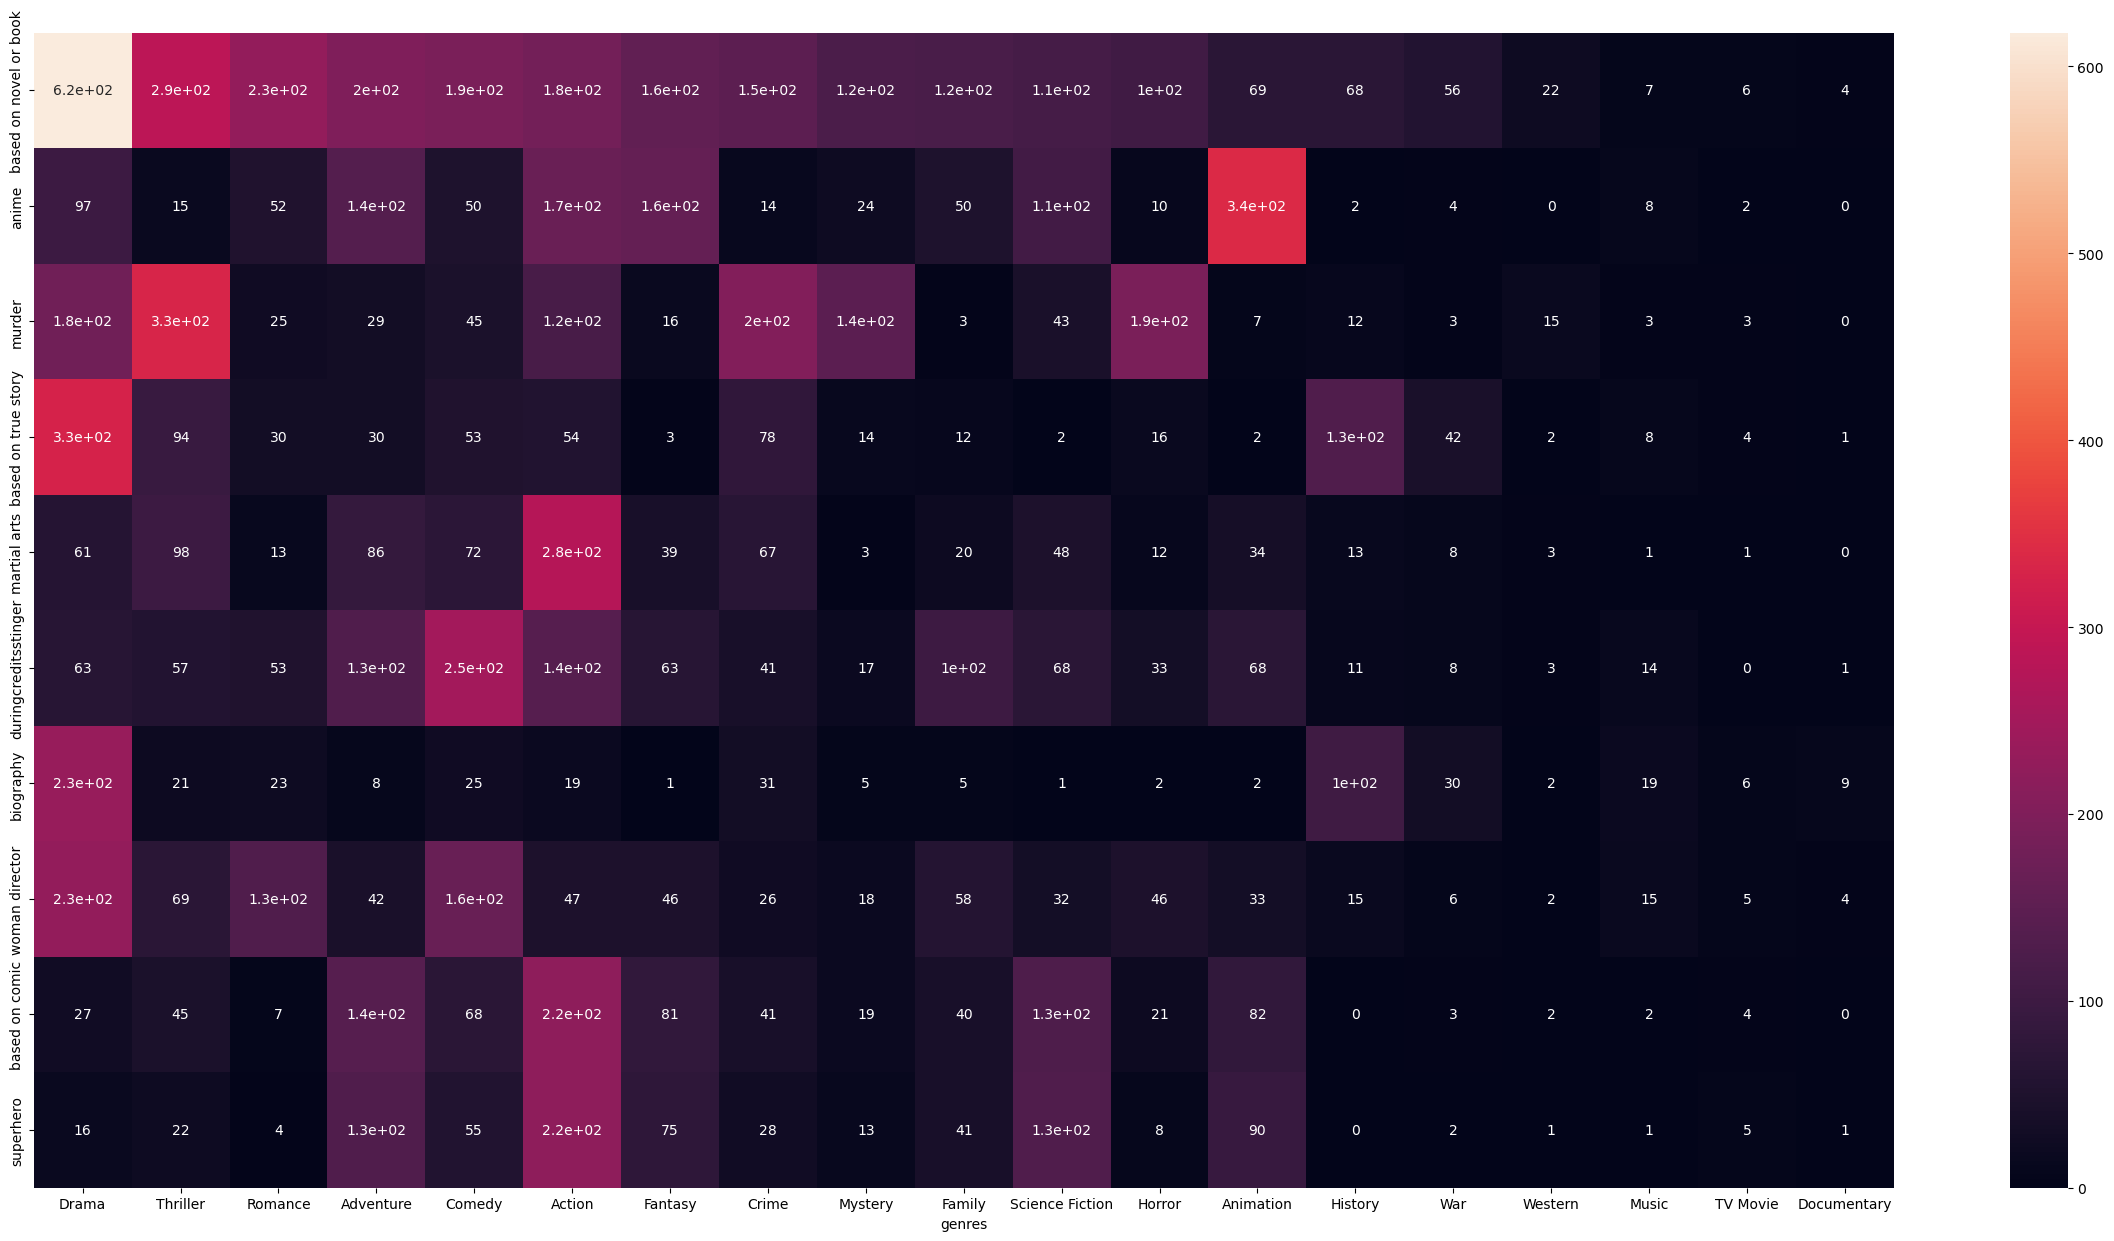

In [215]:
plt.figure(figsize=(30,15))
sns.heatmap(heatmap_df.head(10),annot=True)

# NLP test recommendation 

In [19]:
tokenizer = nltk.RegexpTokenizer(r"[^\W+\d+]+")

In [20]:
sentence  = "Think and wonder, wonder and think.".lower()
new_words = set(tokenizer.tokenize(sentence))
new_sentence = ' '.join(new_words)

In [21]:
new_sentence

'wonder think and'

In [22]:
with open('datasets/stopwords.txt','r') as stopfp:
    stop_words = stopfp.readlines()

In [23]:
stop_words = stop_words[0].replace('"','').split(', ')

In [24]:
overview_tags = []

In [25]:
overviews = movies_df.overview.values

NameError: name 'movies_df' is not defined

In [ ]:
for overview in tqdm(overviews):
    tags = []
    new_overview = ' '.join(set(tokenizer.tokenize(overview.lower())))
    word_token = word_tokenize(new_overview)
    for w in word_token:
        if (w.lower() not in stop_words):
            tags.append(w)
    overview_tags.append(' '.join(tags).lower())

In [16]:
overview_tags = pd.Series(overview_tags)

In [27]:
imdb_ids

array(['tt5755238', 'tt14362112', 'tt15398776', ..., 'tt3321300',
       'tt0116669', 'tt13989030'], dtype=object)

In [14]:
imdb_ids.shape

(9704,)

In [77]:
empty_object = {}

# Creating an empty JSON array
empty_array = []

# Choose one of the above to write to the file
data_to_write = empty_object  # or empty_array

# Writing to the file
with open('try.json', 'w') as file:
    json.dump(data_to_write, file)

In [21]:
stop_words

['0o',
 '0s',
 '3a',
 '3b',
 '3d',
 '6b',
 '6o',
 'a',
 'a1',
 'a2',
 'a3',
 'a4',
 'ab',
 'able',
 'about',
 'above',
 'abst',
 'ac',
 'accordance',
 'according',
 'accordingly',
 'across',
 'act',
 'actually',
 'ad',
 'added',
 'adj',
 'ae',
 'af',
 'affected',
 'affecting',
 'affects',
 'after',
 'afterwards',
 'ag',
 'again',
 'against',
 'ah',
 'ain',
 "ain't",
 'aj',
 'al',
 'all',
 'allow',
 'allows',
 'almost',
 'alone',
 'along',
 'already',
 'also',
 'although',
 'always',
 'am',
 'among',
 'amongst',
 'amoungst',
 'amount',
 'an',
 'and',
 'announce',
 'another',
 'any',
 'anybody',
 'anyhow',
 'anymore',
 'anyone',
 'anything',
 'anyway',
 'anyways',
 'anywhere',
 'ao',
 'ap',
 'apart',
 'apparently',
 'appear',
 'appreciate',
 'appropriate',
 'approximately',
 'ar',
 'are',
 'aren',
 'arent',
 "aren't",
 'arise',
 'around',
 'as',
 "a's",
 'aside',
 'ask',
 'asking',
 'associated',
 'at',
 'au',
 'auth',
 'av',
 'available',
 'aw',
 'away',
 'awfully',
 'ax',
 'ay',
 'az',

In [86]:
with open('plots.json','r') as try_file: json_try = json.load(try_file)

with open("plots.json",'w') as try_file: json.dump({'data':[]},try_file)

In [68]:
pd.DataFrame().from_dict(plot_json).to_json('imdb_data.json')

# Get IMDb plot data

In [35]:
with open('movies_df.pkl','rb') as mp:
    movies_df = pkl.load(mp)

In [46]:
movies_df.columns

Index(['id', 'title', 'overview', 'genres', 'keywords', 'release_date',
       'director', 'director_popularity', 'movie_popularity', 'movie_imdb_id',
       'averageRating', 'numVotes', 'titleType', 'primaryTitle',
       'originalTitle', 'isAdult', 'startYear', 'endYear', 'runtimeMinutes',
       'tags'],
      dtype='object')

In [49]:
type(movies_df['tags'][0])

spacy.tokens.doc.Doc

In [50]:
imdb_ids = movies_df.movie_imdb_id.values

In [59]:
get_movie = imdb.get_movie

In [52]:
data_dict = {'data':[],'imdb_id':[]}

In [33]:
len(imdb_data['data'])

0

In [34]:
data_dict = imdb_data

In [57]:
imdb_ids_copy = imdb_ids

In [58]:
imdb_ids_copy = np.array(list(set(imdb_ids) - set(imdb_data['imdb_id'])))

NameError: name 'imdb_data' is not defined

In [36]:
imdb_ids_copy.shape[0]

9704

In [61]:
start = time.time()
' '.join(get_movie(imdb_ids[0][2:]).data['plot'])
print(time.time() - start)

5.653003931045532


In [ ]:
print('start process')
# i = 0
while (imdb_ids_copy.shape[0] > 0):
    try: 
        for imdb_id in tqdm(imdb_ids_copy): 
            recieved = get_movie(imdb_id[2:]).data
            
            if 'plot' in recieved.keys():
                plot_imdb_data = ' '.join(recieved['plot'])
            else:
                plot_imdb_data = 'no plot'
                
            data_dict['data'].append(plot_imdb_data)
            data_dict['imdb_id'].append(imdb_id)
            imdb_ids_copy = np.delete(imdb_ids_copy,(
                    np.where(imdb_ids_copy == imdb_id)[0]
            ))
            pd.DataFrame().from_dict(data_dict).to_json('plot.json')

    except Exception:
        sleep(180)
    finally:
        sleep(20)
        
print('end process')

start process


  2%|█▌                                                                           | 202/9704 [13:44<9:31:00,  3.61s/it]2024-03-19 04:26:24,354 CRITICAL [imdbpy] C:\Users\LENOVO\anaconda3\lib\site-packages\imdb\_exceptions.py:32: IMDbDataAccessError exception raised; args: ({'errcode': None, 'errmsg': 'None', 'url': 'https://www.imdb.com/title/tt4123432/plotsummary', 'proxy': '', 'exception type': 'IOError', 'original exception': timeout('The read operation timed out')},); kwds: {}
Traceback (most recent call last):
  File "C:\Users\LENOVO\anaconda3\lib\site-packages\imdb\parser\http\__init__.py", line 233, in retrieve_unicode
    response = uopener.open(url)
  File "C:\Users\LENOVO\anaconda3\lib\urllib\request.py", line 523, in open
    response = meth(req, response)
  File "C:\Users\LENOVO\anaconda3\lib\urllib\request.py", line 632, in http_response
    response = self.parent.error(
  File "C:\Users\LENOVO\anaconda3\lib\urllib\request.py", line 555, in error
    result = self._call_ch

> ## *Testing the Results*

In [86]:
len(data_dict['data'])

0

In [89]:
imdb_ids_copy.shape[0]

9704

In [87]:
len(imdb_ids)

9704

In [88]:
len(imdb_ids_copy)

9704

In [78]:
with open('imdb_data.pkl','rb') as mp:
    test_dict = pkl.load(mp)

In [79]:
for title in test_dict['data']:
    print(title['localized title'])

Leo
Trolls Band Together
Oppenheimer
Five Nights at Freddy's
The Creator
Expend4bles


In [295]:
data_length = len(plot_json['data'])
data_length

1

In [294]:
id_length = len(plot_json['imdb_id'])
id_length

1

In [ ]:
data_length == ids_length

In [292]:
last_plot = set(plot_json['data'][data_length - 1])
last_id = set(plot_json['data'][ids_length - 1])



"A 74-year-old lizard named Leo and his turtle friend decide to escape from the terrarium of a Florida school classroom where they have been living for decades. The last year of elementary school as seen through the eyes of a class pet. A jaded 74-year-old lizard named Leo has been stuck in the same Florida classroom for decades with his turtle terrarium-mate. When he learns that he only has one year left to live, he plans to escape to experience life on the outside, but instead gets caught up in his anxious students' problems--such as an impossibly mean substitute teacher.—Alex Hartsell"

> ## Save the Process

In [113]:
pd.DataFrame().from_dict(plot_json).to_json('plot_9704.json')

# with open("plots.json",'w') as json_plots: json.dump(plot_json,json_plots)

In [4]:
plots = pd.read_json('plot_final.json')

In [5]:
plots.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9704 entries, 0 to 999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   data    9666 non-null   object
dtypes: object(1)
memory usage: 151.6+ KB


In [187]:
plots.reset_index(inplace = True)

In [188]:
plots.drop(columns = 'index',inplace = True)
# plots.drop(columns = 'level_0',inplace = True)

In [7]:
plots_df = pd.read_json('plot_final.json')

In [8]:
plots_df[plots_df['data'].isna()].index

Int64Index([ 122, 1457, 1683, 1936, 1955, 2047, 2199, 2424, 3124, 3489, 3862,
            4853, 5169, 5185, 5303, 5308, 5473, 5587, 5821,  591, 5997, 6855,
            7272, 7282, 7752, 7845, 7880, 7908, 8004, 8222, 8251, 8269,  888,
            8942, 9092,  911,  941, 9489],
           dtype='int64')

In [100]:
movies_df.iloc[5796]['overview']

"A fisherman's son is offered the ultimate privilege to study at the Al-Azhar University in Cairo, the epicenter of power of Sunni Islam. Shortly after his arrival, the university’s highest ranking religious leader, the Grand Imam, dies and the young student becomes a pawn in a ruthless power struggle between Egypt's religious and political elite."

In [94]:
with open('plot_final.json','r') as json_plot:
    plot_json = json.load(json_plot)

In [99]:
plot_json['data']['5796']

'documentary seen making epic features never scenes showcases creature shop props footage department visits new behind series interviews limited'

In [92]:
for plot in plots_df[(plots_df['data'].str.find('addams') > 0) & (plots_df['data'].str.find('family') > 0)]['data']:
    print(plot)
    print('='*150)

itt divided struycken hannah busy messing disease named cure morticia mccarthy falls curing christopher mistake uncle sam adams remedy nicole ordinary curry staying alice addams chihuahua home address meanwhile pugsley com carel goes reunion fester unfortunately search normal going human ghostley lives patrick organize horrified given wrong one kevin thomas hair ever gomez discover rare family fugere wish grandma cousin tim printing hart yeo fondacaro vicious new yosam thing turning couple love oblivious due relatives jerry making wednesday inherit mansion end knows error friends slowly someone explode lurch arrives grandmama chance grandpa estelle life daryl hotmail harris amongst phil hoping


In [72]:
plots['data'].iloc[1233]

'woman man spirited despair career growing way finds bouncing distinct witnesses sober law versions invested daphne bad auditioning sister time recent guesthouse intelligent forced secrets jamie turn different accept frank enjoying ways heartbreak decisions disguise nothing year always instead reeling sensitive us enormously opposites meets jack sees events stan waiting brother soon ready woodley fighting fate life dornan unlock exacerbates adventure long sebastian course idealistic albeit sibling adrift might parties something comes regularly term break boy making unpredictable choose places almost sudden living regarding one unable though surprising attractive polar academic free navigating shailene love'

In [277]:
movies_df.iloc[5796]

id                                                                788977
title                                                   Cairo Conspiracy
overview               A fisherman's son is offered the ultimate priv...
genres                                                 [Thriller, Drama]
keywords                                                              []
release_date                                                  2022-10-26
director                                                   [Tarik Saleh]
director_popularity                                              [6.457]
movie_popularity                                                  19.794
movie_imdb_id                                                 tt15452062
averageRating                                                        7.0
numVotes                                                            6413
titleType                                                          movie
primaryTitle                                       

In [278]:
North = get_movie('15452062')

In [283]:
' '.join(North.data['plot'])

"Adam, the son of a fisherman, is offered the privilege to study at the Al-Azhar University in Cairo, the center of power of Sunni Islam. Adam becomes a pawn in the conflict between Egypt's religious and political elites."

In [279]:
for i,plot in enumerate():
    print(i, '=>', plot)

0 => Adam, the son of a fisherman, is offered the privilege to study at the Al-Azhar University in Cairo, the center of power of Sunni Islam. Adam becomes a pawn in the conflict between Egypt's religious and political elites.


In [177]:
plots = plots[(~plots.isna())]

In [178]:
plots.isna().sum()

data    38
dtype: int64

In [184]:
plots[plots.isna()].index

RangeIndex(start=0, stop=9704, step=1)

In [67]:
plots[plots.duplicated()]

,data
1457,None
1683,None
1936,None
1955,None
2047,None
2199,None
2424,None
3124,None
3489,None
3862,None


In [120]:
movies_df.iloc[100]['movie_imdb_id']

'tt1951264'

In [122]:
bete = get_movie('195126')

In [124]:
bete.data

{'localized title': 'Pas si bête',
 'cast': [<Person id:0318373[http] name:_Andrée Gilda_>,
  <Person id:0499151[http] name:_René Lefèvre_>,
  <Person id:0381931[http] name:_Jean Heuzé_>,
  <Person id:0140914[http] name:_Madeleine Carroll_>,
  <Person id:0229052[http] name:_Jean Diéner_>,
  <Person id:0197445[http] name:_Hubert Daix_>,
  <Person id:0290872[http] name:_Charles Frank_>],
 'genres': ['Comedy'],
 'countries': ['France'],
 'country codes': ['fr'],
 'language codes': ['zxx', 'fr'],
 'color info': ['Black and White'],
 'aspect ratio': '1.33 : 1',
 'sound mix': ['Silent'],
 'original air date': '28 Dec 1928 (France)',
 'imdbID': '0195126',
 'languages': ['None', 'French'],
 'title': 'Pas si bête',
 'year': 1928,
 'kind': 'movie',
 'original title': 'Pas si bête',
 'director': [<Person id:0078016[http] name:_André Berthomieu_>],
 'writer': [<Person id:0078016[http] name:_André Berthomieu_>],
 'cinematographer': [<Person id:0490923[http] name:_Maurice Laumann_>],
 'assistant dir

In [119]:
plots[plots.isnull()].index

Int64Index([   0,    1,   10,  100, 1000, 1001, 1002, 1003, 1004, 1005,
            ...
             990,  991,  992,  993,  994,  995,  996,  997,  998,  999],
           dtype='int64', length=9704)

In [ ]:
plots = pd.Series(plots)

In [ ]:
movies_df['plots'] = plots

In [136]:
nlp = spacy.load('en_core_web_lg')

In [137]:
s1 = nlp('Drama Romance murder Action superhero Marvel')
s2 = nlp('Action Drama Crime superhero Space Spiderman')
s3 = nlp('Mystery Romance Thriller Action Science Fiction Spiderman')

In [138]:
s1.similarity(s2)

0.8508921518574479

In [139]:
s2.similarity(s3)

0.8386957024896858

In [140]:
s1.similarity(s3)

0.8532974441550714

In [357]:
# 2019 The Jungle Book 2
# 4201 Batman: Mystery of the Batwoman
# 326 Iron Man 3
# 3802 Batman and Superman: Battle of the Super Sons
# 3221 Bridget Jones's Diary

In [36]:
genres = movies_df['genres'].apply(lambda x: ' '.join(x))

In [37]:
keywords = movies_df['keywords'].apply(lambda x: ' '.join(x))

In [38]:
genres.shape

(9704,)

In [39]:
keywords.shape

(9704,)

In [51]:
tags = []

In [34]:
indeces = movies_df.index

In [35]:
indeces

Int64Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
            ...
            9694, 9695, 9696, 9697, 9698, 9699, 9700, 9701, 9702, 9703],
           dtype='int64', length=9704)

In [52]:
for i in tqdm(indeces):
    tags.append(nlp(f'{genres[i]} {keywords[i]} {overview_tags[i]}'.strip().lower()))

100%|█████████████████████████████████████████████████████████████████████████████| 9704/9704 [01:35<00:00, 101.74it/s]


In [53]:
len(tags)

9704

In [54]:
movies_df['tags'] = tags

In [55]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9704 entries, 0 to 9703
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   9704 non-null   object
 1   title                9704 non-null   object
 2   overview             9704 non-null   object
 3   genres               9704 non-null   object
 4   keywords             9704 non-null   object
 5   release_date         9704 non-null   object
 6   director             9704 non-null   object
 7   director_popularity  9704 non-null   object
 8   movie_popularity     9704 non-null   object
 9   movie_imdb_id        9704 non-null   object
 10  averageRating        9704 non-null   object
 11  numVotes             9704 non-null   object
 12  titleType            9704 non-null   object
 13  primaryTitle         9704 non-null   object
 14  originalTitle        9704 non-null   object
 15  isAdult              9704 non-null   object
 16  startY

In [ ]:
movies_df.info()

In [552]:
movies_df.sample(3)['movie_imdb_id']

5361    tt13804084
3806     tt0381681
2971     tt0102510
Name: movie_imdb_id, dtype: object

In [56]:
movies_df.to_csv('datasets/movies_df.csv')

In [112]:
movies_df_2 = pd.read_csv('datasets/movies_df.csv')

In [109]:
genres_popularity.rename(columns = lambda x: f'popularity_{x}',inplace=True)

In [462]:
sample = tags.iloc[[2019,4201,326,3802,3221]]

In [463]:
sample = sample.apply(lambda x: nlp(str(x).lower()))

In [464]:
sample = pd.DataFrame(sample).rename(columns = {0:'tags'})

In [590]:
movies_df.head()

,id,title,overview,genres,keywords,release_date,director,director_popularity,movie_popularity,movie_imdb_id,averageRating,numVotes,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,tags
0,1075794,Leo,Jaded 74-year-old lizard Leo has been stuck in...,"[Animation, Comedy, Family]","[classroom, musical, bucket list]",2023-11-17,"[Robert Smigel, Robert Marianetti, David Wacht...","[8.964, 8.263, 4.085]",1661.593,tt5755238,7.0,10041,movie,Leo,Leo,0,2023,\N,102,"(animation, comedy, family, classroom, musical..."
1,901362,Trolls Band Together,"When Branch’s brother, Floyd, is kidnapped for...","[Animation, Family, Music, Fantasy, Comedy]","[pop star, brother, musical, sequel, based on ...",2023-10-12,[Walt Dohrn],[10.381],1064.93,tt14362112,6.0,5138,movie,Trolls Band Together,Trolls Band Together,0,2023,\N,91,"(animation, family, music, fantasy, comedy, po..."
2,872585,Oppenheimer,The story of J. Robert Oppenheimer's role in t...,"[Drama, History]","[husband wife relationship, based on novel or ...",2023-07-19,[Christopher Nolan],[31.607],1020.836,tt15398776,8.5,524717,movie,Oppenheimer,Oppenheimer,0,2023,\N,180,"(drama, history, husband, wife, relationship, ..."
3,507089,Five Nights at Freddy's,"Recently fired and desperate for work, a troub...","[Horror, Mystery]","[night shift, child murder, restaurant, custod...",2023-10-25,[Emma Tammi],[9.397],759.232,tt4589218,5.5,73305,movie,Five Nights at Freddy's,Five Nights at Freddy's,0,2023,\N,109,"(horror, mystery, night, shift, child, murder,..."
4,670292,The Creator,Amid a future war between the human race and t...,"[Science Fiction, Action, Thriller]","[artificial intelligence (a.i.), asia, distant...",2023-09-27,[Gareth Edwards],[6.467],702.008,tt11858890,6.9,78610,movie,The Creator,The Creator,0,2023,\N,133,"(science, fiction, action, thriller, artificia..."


In [399]:
sample_overview = movies_df.iloc[[2019,4201,326,3802,3221]][['title','']]

In [400]:
sample_overview['overview'] = sample_overview['overview'].apply(lambda x: nlp(str(x).lower()))

In [402]:
sample_overview.head()

,title,overview
2019,The Jungle Book 2,"(mowgli, has, been, living, in, the, man, -, v..."
4201,Batman: Mystery of the Batwoman,"(as, if, the, penguin, was, n't, enough, to, c..."
326,Iron Man 3,"(when, tony, stark, 's, world, is, torn, apart..."
3802,Batman and Superman: Battle of the Super Sons,"(after, discovering, he, has, powers, ,, 11, -..."
3221,Bridget Jones's Diary,"(a, chaotic, bridget, jones, meets, a, snobbis..."


In [409]:
sample_overview.index

Int64Index([2019, 4201, 326, 3802, 3221], dtype='int64')

In [413]:
sample_overview

,title,overview
2019,The Jungle Book 2,"(mowgli, has, been, living, in, the, man, -, v..."
4201,Batman: Mystery of the Batwoman,"(as, if, the, penguin, was, n't, enough, to, c..."
326,Iron Man 3,"(when, tony, stark, 's, world, is, torn, apart..."
3802,Batman and Superman: Battle of the Super Sons,"(after, discovering, he, has, powers, ,, 11, -..."
3221,Bridget Jones's Diary,"(a, chaotic, bridget, jones, meets, a, snobbis..."


In [477]:
list(range(5))[1:]

[1, 2, 3, 4]

In [478]:
for i in range(5):
    for j in list(range(5))[i:]:
        if i != j:
            print(f'\n {sample_overview.iloc[i].title} to {sample_overview.iloc[j].title}: `',
                  round(sample.iloc[i].tags.similarity(sample.iloc[j].tags),3),'`')


 The Jungle Book 2 to Batman: Mystery of the Batwoman: ` 0.615 `

 The Jungle Book 2 to Iron Man 3: ` 0.516 `

 The Jungle Book 2 to Batman and Superman: Battle of the Super Sons: ` 0.59 `

 The Jungle Book 2 to Bridget Jones's Diary: ` 0.612 `

 Batman: Mystery of the Batwoman to Iron Man 3: ` 0.794 `

 Batman: Mystery of the Batwoman to Batman and Superman: Battle of the Super Sons: ` 0.937 `

 Batman: Mystery of the Batwoman to Bridget Jones's Diary: ` 0.597 `

 Iron Man 3 to Batman and Superman: Battle of the Super Sons: ` 0.865 `

 Iron Man 3 to Bridget Jones's Diary: ` 0.473 `

 Batman and Superman: Battle of the Super Sons to Bridget Jones's Diary: ` 0.537 `


In [593]:
movies_df.query('id == 268')

,id,title,overview,genres,keywords,release_date,director,director_popularity,movie_popularity,movie_imdb_id,averageRating,numVotes,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,tags
1252,268,Batman,Batman must face his most ruthless nemesis whe...,"[Fantasy, Action, Crime]","[dual identity, double life, chemical, crime f...",1989-06-21,[Tim Burton],[16.421],43.96,tt0096895,7.5,397825,movie,Batman,Batman,0,1989,\N,126,"(fantasy, action, crime, dual, identity, doubl..."


In [566]:
_id = 13804084
movies_df.query(f"movie_imdb_id == 'tt{_id}'").tags.values[0]

animation war science fiction superhero world war ii time travel

In [67]:
movies_df['startYear'] = pd.to_datetime(movies_df['startYear']).dt.year

In [142]:
movies_df_2.tags.head()

0    animation comedy family classroom musical buck...
1    animation family music fantasy comedy pop star...
2    drama history husband wife relationship based ...
3    horror mystery night shift child murder restau...
4    science fiction action thriller artificial int...
Name: tags, dtype: object

In [143]:
mv_tags = []

In [146]:
for tag in tqdm(movies_df_2.tags):
    mv_tags.append(nlp(str(tag)))

100%|██████████████████████████████████████████████████████████████████████████████| 9704/9704 [04:53<00:00, 33.07it/s]


In [148]:
len(mv_tags)

9995

In [147]:
movies_df_2.tags = mv_tags

ValueError: Length of values (9995) does not match length of index (9704)

In [ ]:
movies_df_2.to_csv('datasets/movies_df.csv')

In [ ]:
def recommendation_for(imdb_id, year = 2000, freq = 10):
    # movies = movies_df.query(f'startYear >= {year}')
    title = movies_df_2.query(f"movie_imdb_id == 'tt{imdb_id}'").title.values[0]
    scores = []
    indices = movies_df_2.index
    print(f"Best recommendation for `{title}` is:")
    movie_tags = movies_df_2.query(f"movie_imdb_id == 'tt{imdb_id}'").tags.values[0]
    for index in indices:
        scores.append(round(movie_tags.similarity(movies_df_2.iloc[index].tags),3))
    recommends = pd.DataFrame({'imdb_id':movies_df.movie_imdb_id.values,'title':movies_df.title.values,'score':scores,'startYear':movies_df.startYear.values})
    recommends.drop(recommends.query('score == 1').index[0],inplace = True)
    recommends = recommends.query(f'startYear >= {year}')
    recommends = recommends.sort_values(by='score',ascending = False).reset_index().drop(columns = 'index')
    return recommends.head(freq)

In [ ]:
recommendation_for('0241527',freq = 50)

In [12]:
movie = imdb.get_movie("0241527").data
plot = ' '.join(movie['plot'])
new_plot = ' '.join(set(tokenizer.tokenize(plot.lower())))
word_token = word_tokenize(new_plot)
plot_tags = [w for w in word_token if (w.lower() not in stop_words)]

In [13]:
' '.join(plot_tags)

'family granger actually along way brave named inside thrown completely voldemort trade participates celebrating year man intense hagrid wizardry grown smart travels old school hidden gathering far chess sorcerer ron finds quiet richard viewer everything hogwarts mountain somewhere wizarding makes happened student lay soon died fully ones always tale witchcraft something someone dursley mistreated away birthday learns eleventh anxious crash harry incident world quickly dangerous two thinks stone philosopher slave hermione uncle groundskeeper birth truth eleven many bespectacled accepted weasley soumitra valuable haunts imagined wizard tackles trusted orphaned letter learn embarks would potter serving lived daniel grint mundane tells existence meets telling giant however killed ever watson boy terrible bremmer car good average friends magical news reason coltrane new gets come sort beetle live right attend journey troll simon place quidditch suspects ordinary wizards friend planning enr

In [361]:
movies_df.sample(10)['title']

1160           The Big Lebowski
1704    The Angry Birds Movie 2
5869       The Heart of Justice
5217                      50/50
9027                     SPF-18
7655              Angel of Mine
8443      Fantasy Mission Force
9675               Love to Kill
3669                   The King
2142                 Bloodsport
Name: title, dtype: object